<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
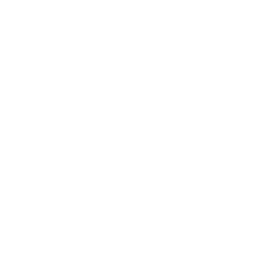
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Steel Mill Rolling Process Monitoring</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Multivariate SPC for hot strip mill thickness and surface quality control &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A hot strip mill rolls steel slabs into thin coil. Eight correlated
process signals (thicknesses, rolling force, roll gap, motor current,
exit temperature) move together when the line is healthy, so monitoring
them one chart at a time misses the joint shifts that matter. This
example builds a multivariate baseline with **PROC MVPMODEL** and then
streams 100 production coils through **PROC MVPMONITOR**, which scores
every coil with a single Hotelling's *T*&sup2; statistic and compares it
to a control limit.

Against an in-control limit of *T*&sup2; = **17.13** (&alpha; = 0.05),
**4 of 100 coils** signal out-of-control — coils **91, 92, 94, and 95**,
exactly the window where a backup-roll chatter burst was injected. Peak
*T*&sup2; reaches **21.91** at coil 95, about **1.3&times;** the limit.
The gradual roll-wear ramp over the later coils lifts the baseline
*T*&sup2; but stays under the limit until the chatter event, so the chart
cleanly separates slow drift from the acute fault that needs immediate
attention.

## Data Sources

- **mill_baseline** &mdash; 50 coils rolled during a known-good stretch
  of the campaign; used to fit the multivariate (PCA) reference model.
- **mill_stream** &mdash; 100 coils from the live line. Coils 1&ndash;55
  run in control; roll wear develops gradually over coils 56&ndash;100;
  a backup-roll chatter burst hits coils 91&ndash;95.
- **Process variables** (6): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> The environment runs unlicensed, so datasets are capped at 100
> observations. The scenario is sized to that cap: the disturbance is
> placed late in a 100-coil stream rather than at coil 2,800 of 5,000.

---

### Step 1 &mdash; Build the multivariate reference model

`PROC MVPMODEL` performs a principal component analysis of the six
process variables on the in-control baseline and writes the loadings,
eigenvalues, and centering/scaling to `mill_model`. Three components are
retained. This model defines what "normal" looks like as a single
multivariate region rather than six independent ranges.

In [1]:
data mill_baseline;
  call streaminit(66);
  do coil_id = 1 to 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    output;
  end;
run;

proc mvpmodel data=mill_baseline outmodel=mill_model;
  var entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ncomp=3;
run;


                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         entry_thicknessexit_thicknessrolling_force  roll_gapmotor_current exit_temp
  entry_thickness    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  exit_thickness   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  rolling_force   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  roll_gap   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  motor_current    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  exit_temp    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3

NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### Step 2 &mdash; Stream the production coils and score them

`PROC MVPMONITOR` projects each of the 100 production coils onto the
saved model and computes its Hotelling's *T*&sup2;. The procedure derives
the control limit from the model dimensions and the default
&alpha; = 0.05, then flags any coil whose *T*&sup2; exceeds it. Results,
including the `_TSQUARED`, `_LIMIT`, and `_SIGNAL` columns, are written
to `mill_scores` keyed by `coil_id`.

In [2]:
data mill_stream;
  call streaminit(42);
  do coil_id = 1 to 100;
    /* roll wear ramps 0 -> 1 over coils 56-100 */
    wear    = max(0, coil_id - 55) / 45;
    /* backup-roll chatter burst on coils 91-95 */
    chatter = (coil_id >= 91 and coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    drop wear chatter;
    output;
  end;
run;

proc mvpmonitor data=mill_stream model=mill_model
                out=mill_scores;
  var entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
run;


                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4




NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


The procedure summary reports the control limit and the signal
count. Below, the printed slice around the disturbance shows that
baseline coils sit well under the limit while the chatter window drives
four coils above it.

In [3]:
/* Flag out-of-control coils and capture the alarm T2 for plotting */
data mill_scores;
  set mill_scores;
  if _SIGNAL = 1 then t2_alarm = _TSQUARED;
  else t2_alarm = .;
run;

proc print data=mill_scores(firstobs=88 obs=96) noobs;
  var coil_id _TSQUARED _LIMIT _SIGNAL;
  title 'T2 scores across the chatter window (coils 88-96)';
run;

                                   T2 scores across the chatter window (coils 88-96)                                    

COIL_ID  _TSQUARED     _LIMIT  _SIGNAL
     88   9.983151  17.133408        0
     89   2.915646  17.133408        0
     90    7.80613  17.133408        0
     91  18.813814  17.133408        1
     92  18.249361  17.133408        1
     93  16.638221  17.133408        0
     94  17.981792  17.133408        1
     95  21.912329  17.133408        1
     96   5.118574  17.133408        0

... 4 more observations (showing 9 of 13)



NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### Step 3 &mdash; Multivariate control chart

The chart overlays the per-coil *T*&sup2; against its control limit.
Out-of-control coils are highlighted in red; the dashed vertical marker
flags the onset of the chatter burst. The slow rise toward the right is
roll wear lifting the baseline; the four red points are the acute
chatter fault.

                                   T2 scores across the chatter window (coils 88-96)                                    



NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


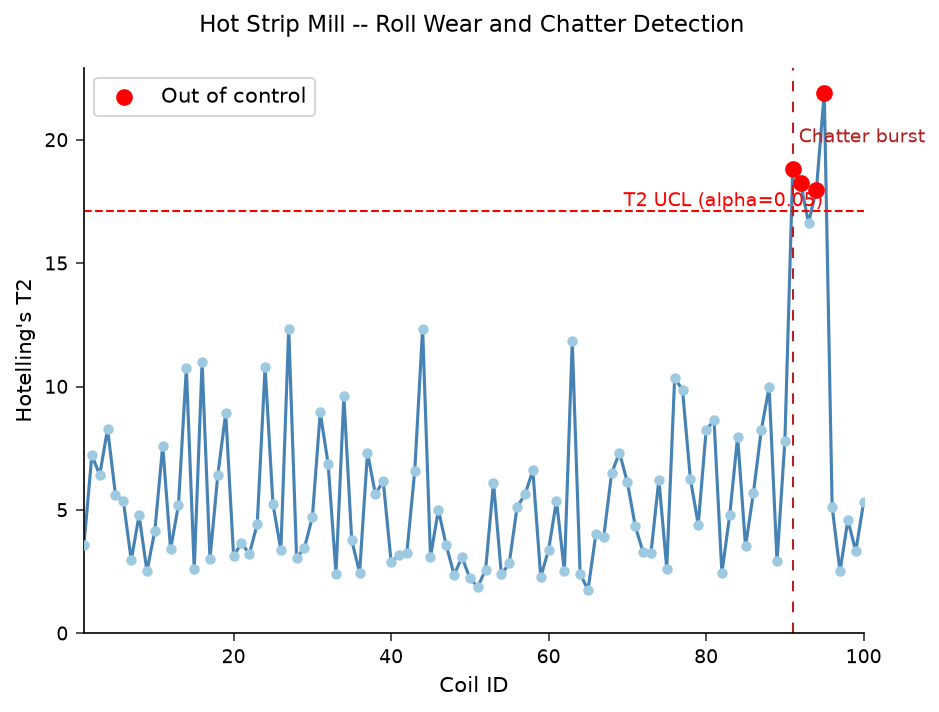

In [4]:
proc sgplot data=mill_scores;
  series  x=coil_id y=_TSQUARED /
          lineattrs=(color=steelblue thickness=1.5);
  scatter x=coil_id y=_TSQUARED /
          markerattrs=(symbol=circlefilled size=4 color=cx9ecae1);
  scatter x=coil_id y=t2_alarm /
          markerattrs=(symbol=circlefilled size=7 color=red)
          legendlabel='Out of control';
  refline _LIMIT / axis=y
          label='T2 UCL (alpha=0.05)'
          lineattrs=(color=red pattern=dash);
  refline 91 / axis=x label='Chatter burst'
          lineattrs=(color=firebrick pattern=shortdash);
  xaxis label='Coil ID' min=1 max=100;
  yaxis label="Hotelling's T2" min=0;
  title 'Hot Strip Mill -- Roll Wear and Chatter Detection';
run;

---

### Step 4 &mdash; Quantify the out-of-control coils

The out-of-control coils are routed to a separate dataset for the
quality desk. `PROC MEANS` contrasts the *T*&sup2; level of the flagged
coils against the in-control population, and the flagged coils are
exported for downstream scrap/rework routing.

In [5]:
data mill_ooc;
  set mill_scores;
  if _SIGNAL = 1;
run;

proc means data=mill_scores n mean max maxdec=2;
  class _SIGNAL;
  var _TSQUARED;
  title 'T2 by control state (0 = in control, 1 = signal)';
run;

proc print data=mill_ooc noobs;
  var coil_id _TSQUARED _LIMIT;
  title 'Out-of-control coils flagged for inspection';
run;

proc export data=mill_ooc
            outfile='steel_mill_ooc_coils.csv'
            dbms=csv replace;
run;

                                    T2 by control state (0 = in control, 1 = signal)                                    

                                                  The MEANS Procedure

                                             Analysis Variable : _TSQUARED

        _SIGNAL           N Obs           Mean        Maximum
        -----------------------------------------------------
        0                    96           5.39          16.64
        1                     4          19.24          21.91
        -----------------------------------------------------

                                      Out-of-control coils flagged for inspection                                       

COIL_ID  _TSQUARED     _LIMIT
     91  18.813814  17.133408
     92  18.249361  17.133408
     94  17.981792  17.133408
     95  21.912329  17.133408



NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Findings

- **Coils monitored**: 100; **control limit** *T*&sup2; = **17.13**
  (&alpha; = 0.05).
- **Out-of-control coils**: **4** &mdash; coils **91, 92, 94, 95**, all
  inside the injected chatter window (91&ndash;95). Coil 93 peaks at
  *T*&sup2; = 16.64, just under the limit.
- **Peak severity**: *T*&sup2; = **21.91** at coil 95 (about 1.3&times;
  the limit); the in-control coils average *T*&sup2; &asymp; **5.4**.
- **Wear vs. fault**: the gradual roll-wear ramp lifts the later-coil
  baseline but never crosses the limit on its own, so the single
  multivariate chart distinguishes slow drift (watch) from the acute
  chatter event (act).
- **Action**: the four flagged coils are exported to
  `steel_mill_ooc_coils.csv` for inspection and scrap/rework routing;
  the chatter signature points to the backup-roll bearing for inspection
  before the next campaign.

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>